# Data Loading and Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Loading the datasets
movies = pd.read_csv('/content/drive/MyDrive/Movie Recommendation System/movies_metadata.csv', low_memory=False)
ratings = pd.read_csv('/content/drive/MyDrive/Movie Recommendation System/ratings_small.csv')

print("Movies dataset loaded successfully:")
print(movies.head())

print("\nRatings dataset loaded successfully:")
print(ratings.head())

Movies dataset loaded successfully:
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709                en   
1                             

In [ ]:
# Cleaning up the movies metadata
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies = movies.dropna(subset=['id'])
movies['id'] = movies['id'].astype(int)

# Keeping only necessary movie metadata
movie_titles = movies[['id', 'title']]

# Merging the movie titles with ratings
df = pd.merge(ratings, movie_titles, left_on='movieId', right_on='id')
df = df.drop(columns=['id', 'timestamp'])

filtered_df = pd.merge(ratings, movies, left_on='movieId', right_on='id')
filtered_df = filtered_df[['userId', 'movieId', 'rating', 'title']]

print("Merged dataset preview:")
df.head()

Merged dataset preview:


/tmp/ipython-input-30-3219632713.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['id'] = movies['id'].astype(int)


,userId,movieId,rating,title
0,1,1371,2.5,Rocky III
1,1,1405,1.0,Greed
2,1,2105,4.0,American Pie
3,1,2193,2.0,My Tutor
4,1,2294,2.0,Jay and Silent Bob Strike Back


# Popular Movies

In [ ]:
# finding most popular movies based on rating count and average rating
popular_movies = ratings.groupby('movieId').agg({
    'rating': ['mean', 'count']
}).reset_index()

popular_movies.columns = ['movieId', 'avg_rating', 'rating_count']

# Merging with the titles
popular_movies = popular_movies.merge(movies[['id', 'title']], left_on='movieId', right_on='id')
popular_movies = popular_movies.sort_values(['rating_count', 'avg_rating'], ascending=False)

# Selecting the top-N popular movies
top_n_popular = popular_movies.head(10)[['title', 'avg_rating', 'rating_count']]
print("Top 10 Popular Movies (fallback):")
print(top_n_popular)

Top 10 Popular Movies (fallback):
                                  title  avg_rating  rating_count
212  Terminator 3: Rise of the Machines    4.256173           324
228            The Million Dollar Hotel    4.487138           311
397                             Solaris    4.138158           304
184                        The 39 Steps    4.221649           291
321                     Monsoon Wedding    3.706204           274
352                  Once Were Warriors    4.303279           244
66                    Three Colors: Red    3.945175           228
407                     Men in Black II    4.256696           224
495          The Passion of Joan of Arc    3.483945           218
394                         Silent Hill    3.674419           215


# Creating User-Item Matrix and Training KNN Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error
import numpy as np

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

train_pivot = train_data.pivot_table(index='title', columns='userId', values='rating').fillna(0)
train_sparse_matrix = csr_matrix(train_pivot.values)

model_eval = NearestNeighbors(metric='cosine', algorithm='brute')
model_eval.fit(train_sparse_matrix)

y_true = []
y_pred = []

for _, row in test_data.iterrows():
    user_id = row['userId']
    movie_title = row['title']
    true_rating = row['rating']

    y_true.append(true_rating)

    if movie_title in train_pivot.index:
        movie_index = train_pivot.index.get_loc(movie_title)

        distances, indices = model_eval.kneighbors(train_pivot.iloc[movie_index, :].values.reshape(1, -1), n_neighbors=11)

        neighbor_indices = indices.flatten()[1:]
        neighbor_similarities = 1 - distances.flatten()[1:]
        neighbor_titles = train_pivot.index[neighbor_indices]

        weighted_sum = 0
        similarity_sum = 0

        for i, neighbor_idx in enumerate(neighbor_indices):
            neighbor_title = train_pivot.index[neighbor_idx]

            user_rating_for_neighbor = train_pivot.loc[neighbor_title, user_id]

            if user_rating_for_neighbor > 0:
                similarity = neighbor_similarities[i]
                weighted_sum += (user_rating_for_neighbor * similarity)
                similarity_sum += similarity

        if similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum
        else:
            movie_ratings = train_pivot.loc[movie_title]
            predicted_rating = movie_ratings[movie_ratings > 0].mean() if not movie_ratings[movie_ratings > 0].empty else df['rating'].mean()

        y_pred.append(predicted_rating)

    else:
        y_pred.append(df['rating'].mean())

y_pred = np.nan_to_num(y_pred, nan=df['rating'].mean())

In [ ]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Model Evaluation Results:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Model Evaluation Results:
Root Mean Squared Error (RMSE): 1.0139


In [ ]:
from scipy.sparse import csr_matrix

# Creating user-item pivot table
movie_pivot = filtered_df.pivot_table(index='title', columns='userId', values='rating').fillna(0)

# Converting it to sparse matrix
movie_sparse_matrix = csr_matrix(movie_pivot.values)

print("Shape of the user-item matrix:", movie_pivot.shape)
movie_pivot.head()

Shape of the user-item matrix: (2794, 671)


userId,1,2,3,4,5,6,7,8,9,10,...,662,663,664,665,666,667,668,669,670,671
title,,,,,,,,,,,,,,,,,,,,,
!Women Art Revolution,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Gator Bait,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Twas the Night Before Christmas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...And God Created Woman,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00 Schneider - Jagd auf Nihil Baxter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Building and training the model
model = NearestNeighbors(metric='cosine', algorithm='brute')
print("Training the Nearest Neighbors model...")
model.fit(movie_pivot.values)
print("Training complete")

Training the Nearest Neighbors model...
Training complete


In [ ]:
# Defining the Recommendation Function

def get_recommendations(movie_title, n=10):
    if movie_title not in movie_pivot.index:
        print(f"'{movie_title}' not found in dataset. Showing Top {n} Popular Movies instead:")
        return top_n_popular.head(n)[['title', 'avg_rating', 'rating_count']]

    movie_index = movie_pivot.index.get_loc(movie_title)
    distances, indices = model.kneighbors(movie_pivot.iloc[movie_index, :].values.reshape(1, -1), n_neighbors=n+1)

    recommendations = []
    print(f"\nTop {n} Recommendations if you liked '{movie_title}':")
    for i in range(1, len(distances.flatten())):
        recommended_movie = movie_pivot.index[indices.flatten()[i]]
        similarity_score = 1 - distances.flatten()[i]
        recommendations.append((recommended_movie, similarity_score))
        print(f"{i}. {recommended_movie} (similarity: {similarity_score:.3f})")

    return pd.DataFrame(recommendations, columns=['Recommended Movie', 'Similarity Score'])


# def get_recommendations(movie_title, n=10):
#     try:
#         movie_index = movie_pivot.index.get_loc(movie_title)
#     except KeyError:
#         print(f"Error: Movie '{movie_title}' not found in the dataset.")
#         return

#     distances, indices = model.kneighbors(movie_pivot.iloc[movie_index, :].values.reshape(1, -1), n_neighbors=n+1)

#     print(f"\nTop {n} Recommendations if you liked '{movie_title}' ")
#     for i in range(1, len(distances.flatten())):
#         recommended_movie = movie_pivot.index[indices.flatten()[i]]
#         similarity_score = 1 - distances.flatten()[i]
#         print(f"{i}. {recommended_movie} (similarity: {similarity_score:.3f})")

In [ ]:
# Precomputing the top-N popular movies (for fallback)
popularity_df = filtered_df.groupby('title').agg({'rating': ['mean', 'count']})
popularity_df.columns = ['avg_rating', 'rating_count']
top_n_popular = popularity_df.sort_values(['rating_count', 'avg_rating'], ascending=False).reset_index()

In [ ]:
# def get_top_n_popular_movies(df, n=5):

#     popularity_df = df.groupby('title').agg({'rating': ['mean', 'count']})
#     popularity_df.columns = ['average_rating', 'rating_count']
#     popularity_df = popularity_df.sort_values(['rating_count', 'average_rating'], ascending=False)
#     return popularity_df.head(n)

# Evaluation Matrix

In [ ]:
import numpy as np

def get_user_rated_movies(user_index):
    user_ratings = movie_pivot.iloc[:, user_index]
    return user_ratings[user_ratings > 0].index.tolist()

def get_top_k_recommendations(movie_title, k=5):
    try:
        movie_index = movie_pivot.index.get_loc(movie_title)
    except KeyError:
        return None

    distances, indices = model.kneighbors(movie_pivot.iloc[movie_index, :].values.reshape(1, -1), n_neighbors=k+1)
    recommended_movies = movie_pivot.index[indices.flatten()[1:]]
    return recommended_movies

def evaluate_user(user_index, k=5):
    rated_movies = get_user_rated_movies(user_index)
    if len(rated_movies) < 2:
        return None

    np.random.shuffle(rated_movies)
    test_movie = rated_movies.pop()
    recommended = get_top_k_recommendations(test_movie, k)

    if recommended is None or recommended.empty:
        return None

    hits = sum(1 for movie in rated_movies if movie in recommended)
    precision = hits / k
    recall = hits / len(rated_movies) if rated_movies else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    return precision, recall, f1

def evaluate_all_users(k=5):
    precision_scores, recall_scores, f1_scores = [], [], []
    failed_users = 0

    for i in range(movie_pivot.shape[1]):
        result = evaluate_user(i, k)
        if result:
            p, r, f = result
            precision_scores.append(p)
            recall_scores.append(r)
            f1_scores.append(f)
        else:
            failed_users += 1

    return {
        "precision": np.mean(precision_scores),
        "recall": np.mean(recall_scores),
        "f1": np.mean(f1_scores),
        "evaluated_users": len(precision_scores),
        "skipped_users": failed_users
    }

# Printing Evaluation:
results = evaluate_all_users(k=5)
print(f"Evaluated Users: {results['evaluated_users']}")
print(f"Average Precisionat at k = 5: {results['precision']:.3f}")
print(f"Average Recall at k = 5: {results['recall']:.3f}")
print(f"Average F1-Score at k = 5: {results['f1']:.3f}")
print(f"Skipped Users: {results['skipped_users']}")

Evaluated Users: 671
Average Precisionat at k = 5: 0.365
Average Recall at k = 5: 0.049
Average F1-Score at k = 5: 0.080
Skipped Users: 0


K=1 -> Precision: 0.390, Recall: 0.011, F1: 0.020
K=3 -> Precision: 0.370, Recall: 0.030, F1: 0.053
K=5 -> Precision: 0.362, Recall: 0.048, F1: 0.078
K=10 -> Precision: 0.325, Recall: 0.085, F1: 0.119
K=25 -> Precision: 0.297, Recall: 0.181, F1: 0.189


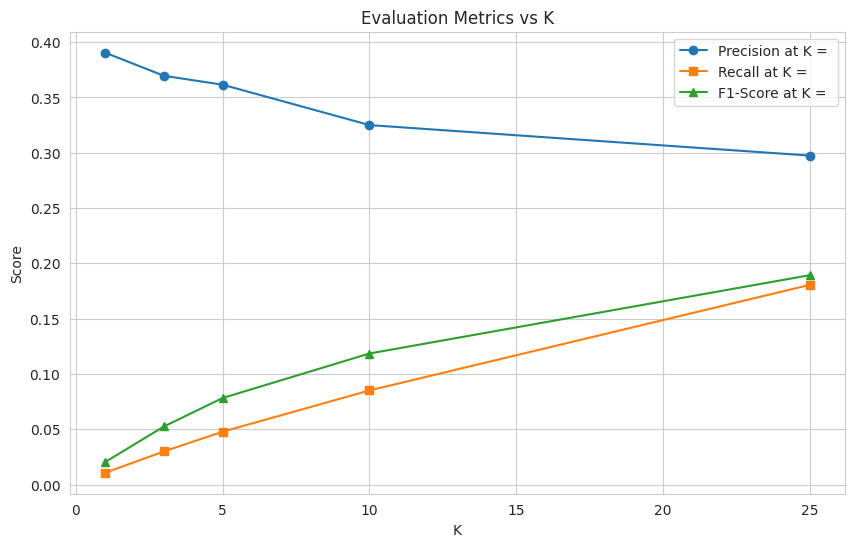

In [ ]:
import matplotlib.pyplot as plt

# Plotting different values of k
def plot_metrics_for_k_values(k_values):
    precision_list, recall_list, f1_list = [], [], []

    for k in k_values:
        results = evaluate_all_users(k)
        precision_list.append(results['precision'])
        recall_list.append(results['recall'])
        f1_list.append(results['f1'])
        print(f"K={k} -> Precision: {results['precision']:.3f}, Recall: {results['recall']:.3f}, F1: {results['f1']:.3f}")

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, precision_list, marker='o', label='Precision at K = ')
    plt.plot(k_values, recall_list, marker='s', label='Recall at K = ')
    plt.plot(k_values, f1_list, marker='^', label='F1-Score at K = ')
    plt.xlabel('K')
    plt.ylabel('Score')
    plt.title('Evaluation Metrics vs K')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plotting
plot_metrics_for_k_values([1, 3, 5, 10, 25])

# Visualizations

Distribution of Movie Ratings

/tmp/ipython-input-41-1485106231.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


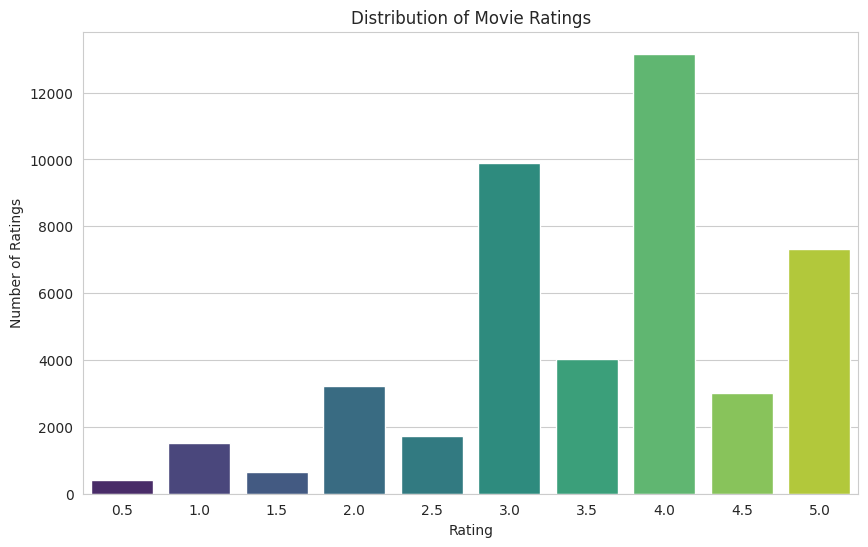

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Ratings distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()

 Top 20 Most Rated Movies

/tmp/ipython-input-42-2341751799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_movies.values, y=top_20_movies.index, palette='mako')


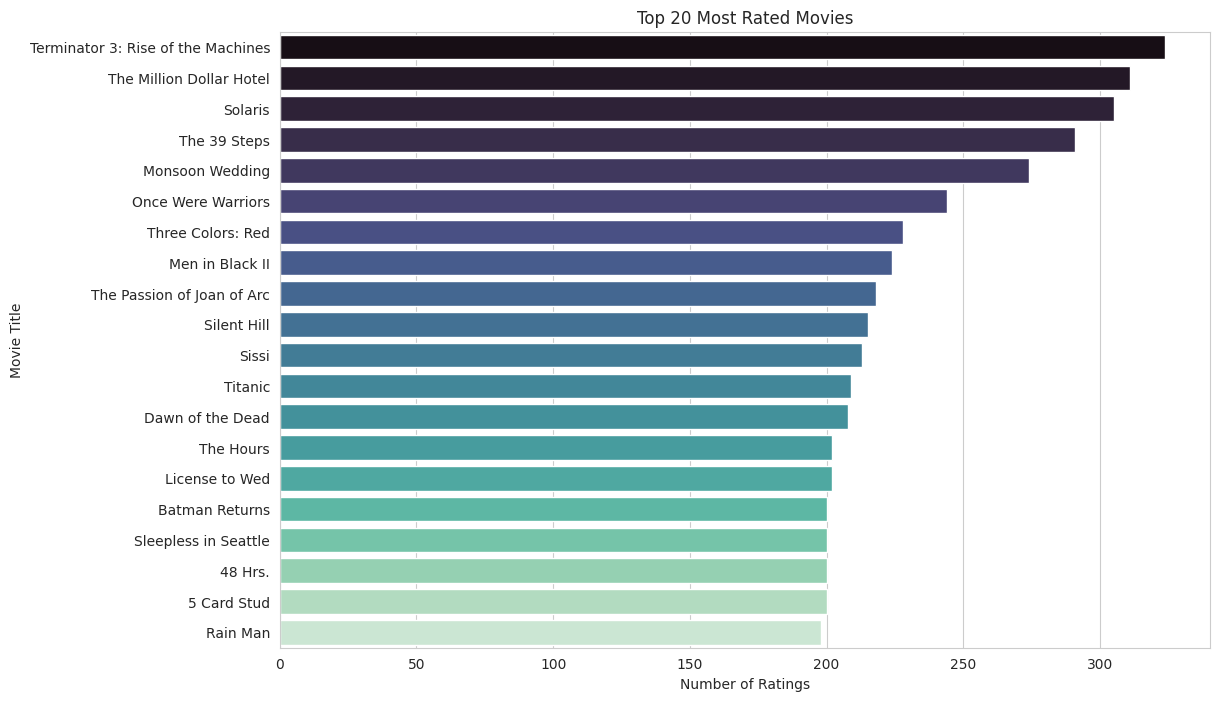

In [ ]:
# Top 20 Most Rated Movies
plt.figure(figsize=(12, 8))
top_20_movies = df['title'].value_counts().head(20)
sns.barplot(x=top_20_movies.values, y=top_20_movies.index, palette='mako')
plt.title('Top 20 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()

Distribution of Ratings Per User

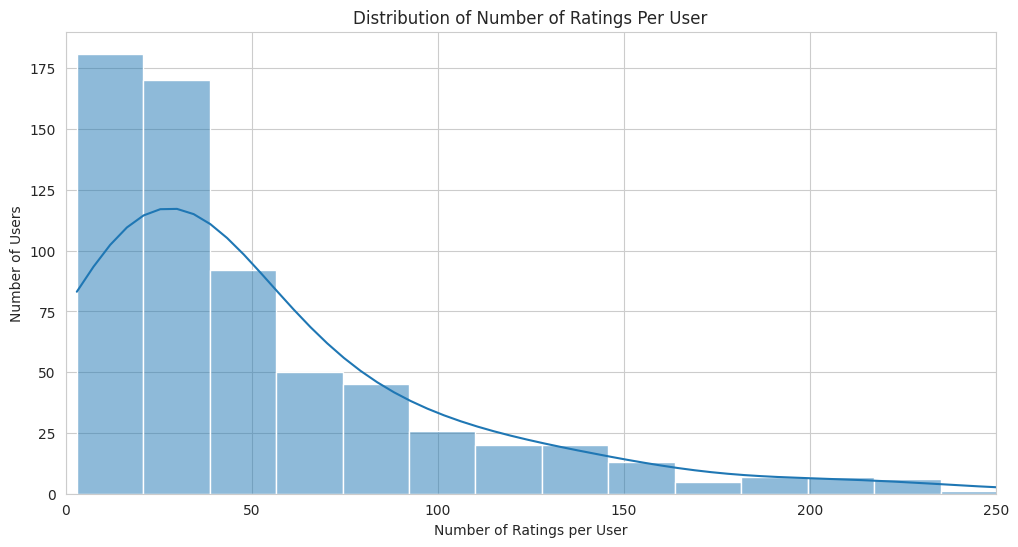

In [ ]:
# Number of ratings per user
user_rating_counts = df['userId'].value_counts()
plt.figure(figsize=(12, 6))
sns.histplot(user_rating_counts, bins=50, kde=True)
plt.title('Distribution of Number of Ratings Per User')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.xlim(0, 250)
plt.show()

In [ ]:
# Getting Recomendations (Testing)
sample_movies = ['Rocky III', '!Women Art Revolution', 'Pulp Fiction (1994)']

for movie in sample_movies:
    get_recommendations(movie)


Top 10 Recommendations if you liked 'Rocky III':
1. Rocky V (similarity: 0.643)
2. Rocky IV (similarity: 0.557)
3. The Discovery of Heaven (similarity: 0.554)
4. Sweet Sixteen (similarity: 0.552)
5. Blood Diamond (similarity: 0.467)
6. Two Weeks Notice (similarity: 0.415)
7. American Pie (similarity: 0.373)
8. Jurassic Park (similarity: 0.371)
9. Heathers (similarity: 0.370)
10. Kiss of the Dragon (similarity: 0.362)

Top 10 Recommendations if you liked '!Women Art Revolution':
1. Premium Rush (similarity: 0.996)
2. The Eleventh Victim (similarity: 0.759)
3. Shadow Run (similarity: 0.759)
4. Fantasía... 3 (similarity: 0.651)
5. Young Mr. Lincoln (similarity: 0.651)
6. Day of the Reaper (similarity: 0.651)
7. Verlengd Weekend (similarity: 0.651)
8. Gladiator (similarity: 0.651)
9. Gaslight (similarity: 0.651)
10. Girl Shy (similarity: 0.651)
'Pulp Fiction (1994)' not found in dataset. Showing Top 10 Popular Movies instead:
